# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [89]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [90]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

36
{'../outputs/2026-07-19/00_tbzhuDOP_adder_1/points.csv': 'tbzhuDOP_adder', '../outputs/2026-07-19/00_tbzhuDOP_max_1/points.csv': 'tbzhuDOP_max', '../outputs/2026-07-19/00_gfn_multiplier_1/points.csv': 'gfn_multiplier', '../outputs/2026-07-19/00_tbzhuDOP_multiplier_1/points.csv': 'tbzhuDOP_multiplier', '../outputs/2026-07-19/00_gfn_max_1/points.csv': 'gfn_max', '../outputs/2026-07-19/00_gfn_adder_1/points.csv': 'gfn_adder', '../outputs/2026-06-02/01:49:15_tbzhuLinear0_k2_81413/points.csv': 'tbzhuLinear0_k2', '../outputs/2026-06-02/01:51:19_tbzhuDOP0_k2_81414/points.csv': 'tbzhuDOP0_k2', '../outputs/2026-06-02/00:23:02_tbzhuDOP0_dalu_81414/points.csv': 'tbzhuDOP0_dalu', '../outputs/2026-06-02/00:21:33_tbzhuLinear0_dalu_81413/points.csv': 'tbzhuLinear0_dalu', '../outputs/2026-07-08/07:29:33_tbzhuDOP_apex1_10373/points.csv': 'tbzhuDOP_apex1', '../outputs/2026-07-08/07:29:33_tbzhuDOP_bc0_10372/points.csv': 'tbzhuDOP_bc0', '../outputs/2026-07-08/07:29:33_tbzhuDOP_C5315_10374/points.csv': 

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. The strict hypervolume uses `(1, 1)` as its reference and therefore measures improvements in both objectives. Extended hypervolume uses `(1.05, 1.05)`, so a front that improves only size or only depth can have positive dominated area. The original point alone has extended hypervolume `0.05 * 0.05 = 0.0025`; compare against that baseline rather than interpreting any positive extended hypervolume as an improvement.

In [91]:
HYPERVOLUME_REFERENCE = (1.0, 1.0)
EXTENDED_HYPERVOLUME_REFERENCE = (1.05, 1.05)
EXTENDED_HYPERVOLUME_ORIGINAL_BASELINE = (
    (EXTENDED_HYPERVOLUME_REFERENCE[0] - 1.0)
    * (EXTENDED_HYPERVOLUME_REFERENCE[1] - 1.0)
)


def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=HYPERVOLUME_REFERENCE):
    """2D minimization hypervolume relative to the supplied reference point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [92]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front, HYPERVOLUME_REFERENCE),
            "extended_hypervolume": hypervolume_min_2d(
                front, EXTENDED_HYPERVOLUME_REFERENCE
            ),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
# summary_df.loc[summary_df['run_name'].str.startswith('ppo')]
print(summary_df['run_name'].unique())
summary_df

['tbzhuDOP0_c1355' 'tbzhuDOP_C1355' 'tbzhuLinear0_c1355' 'zhuDOP_c1355'
 'zhuLinear_c1355' 'tbzhuDOP0_c5315' 'tbzhuDOP_C5315' 'tbzhuLinear0_c5315'
 'zhuDOP_c5315' 'zhuLinear_c5315' 'gfn_adder' 'tbzhuDOP_adder'
 'tbzhuDOP0_apex1' 'tbzhuDOP_apex1' 'tbzhuLinear0_apex1' 'zhuDOP_apex1'
 'zhuLinear_apex1' 'tbzhuDOP0_bc0' 'tbzhuDOP_bc0' 'tbzhuLinear0_bc0'
 'zhuDOP_bc0' 'zhuLinear_bc0' 'tbzhuDOP0_dalu' 'tbzhuDOP_dalu'
 'tbzhuLinear0_dalu' 'zhuDOP_dalu' 'zhuLinear_dalu' 'tbzhuDOP0_k2'
 'tbzhuDOP_k2' 'tbzhuLinear0_k2' 'zhuDOP_k2' 'zhuLinear_k2' 'gfn_max'
 'tbzhuDOP_max' 'gfn_multiplier' 'tbzhuDOP_multiplier']


,run_name,run_id,circuit,hypervolume,extended_hypervolume,number of nondominated points
0,tbzhuDOP0_c1355,0,C1355,0.081044,0.112558,1
1,tbzhuDOP0_c1355,1,C1355,0.081044,0.112558,1
2,tbzhuDOP0_c1355,2,C1355,0.071963,0.101554,2
3,tbzhuDOP0_c1355,3,C1355,0.072039,0.101630,1
4,tbzhuDOP0_c1355,4,C1355,0.080815,0.112329,3
...,...,...,...,...,...,...
350,tbzhuDOP_multiplier,2,multiplier,0.004442,0.014204,1
351,tbzhuDOP_multiplier,3,multiplier,0.004443,0.014206,2
352,tbzhuDOP_multiplier,4,multiplier,0.004437,0.014193,1
353,tbzhuDOP_multiplier,5,multiplier,0.004442,0.014203,2


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [93]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        extended_hypervolume_mean=("extended_hypervolume", "mean"),
        extended_hypervolume_std=("extended_hypervolume", "std"),
        extended_hypervolume_min=("extended_hypervolume", "min"),
        extended_hypervolume_max=("extended_hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["extended_hypervolume_stderr"] = (
    aggregate_summary_df["extended_hypervolume_std"]
    / aggregate_summary_df["n_runs"].pow(0.5)
)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,extended_hypervolume_mean,extended_hypervolume_std,extended_hypervolume_min,extended_hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,extended_hypervolume_stderr,nondominated_stderr
0,gfn_adder,adder,10,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.000000,0.000000,1,1,0.000000e+00,0.000000e+00,0.000000
1,gfn_max,max,10,0.007032,0.000614,0.005728,0.007691,0.027205,0.000962,0.026034,0.028731,7.600000,1.264911,5,9,1.941575e-04,3.042885e-04,0.400000
2,gfn_multiplier,multiplier,8,0.004444,0.000001,0.004441,0.004445,0.014207,0.000002,0.014204,0.014210,1.750000,0.707107,1,3,3.839931e-07,5.341627e-07,0.250000
3,tbzhuDOP0_apex1,apex1,10,0.098350,0.005023,0.091790,0.103620,0.132539,0.005977,0.124761,0.138819,2.800000,0.918937,2,4,1.588310e-03,1.890198e-03,0.290593
4,tbzhuDOP0_bc0,bc0,10,0.211114,0.007436,0.201978,0.220457,0.259746,0.008265,0.249629,0.270035,3.100000,1.100505,1,4,2.351363e-03,2.613670e-03,0.348010
5,tbzhuDOP0_c1355,C1355,10,0.075557,0.006229,0.063034,0.081044,0.105917,0.007574,0.090702,0.112558,1.600000,0.843274,1,3,1.969904e-03,2.395055e-03,0.266667
6,tbzhuDOP0_c5315,C5315,10,0.077858,0.006756,0.067088,0.090851,0.108425,0.008128,0.095493,0.124162,2.300000,1.059350,1,4,2.136438e-03,2.570328e-03,0.334996
7,tbzhuDOP0_dalu,dalu,10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.800000,0.632456,1,3,0.000000e+00,0.000000e+00,0.200000
8,tbzhuDOP0_k2,k2,10,0.197093,0.003165,0.192736,0.201397,0.244362,0.003370,0.239898,0.249013,3.300000,1.337494,2,5,1.000821e-03,1.065581e-03,0.422953
9,tbzhuDOP_C1355,C1355,10,0.075588,0.004614,0.071963,0.081044,0.105948,0.005607,0.101554,0.112558,1.500000,0.527046,1,2,1.459159e-03,1.773180e-03,0.166667


9


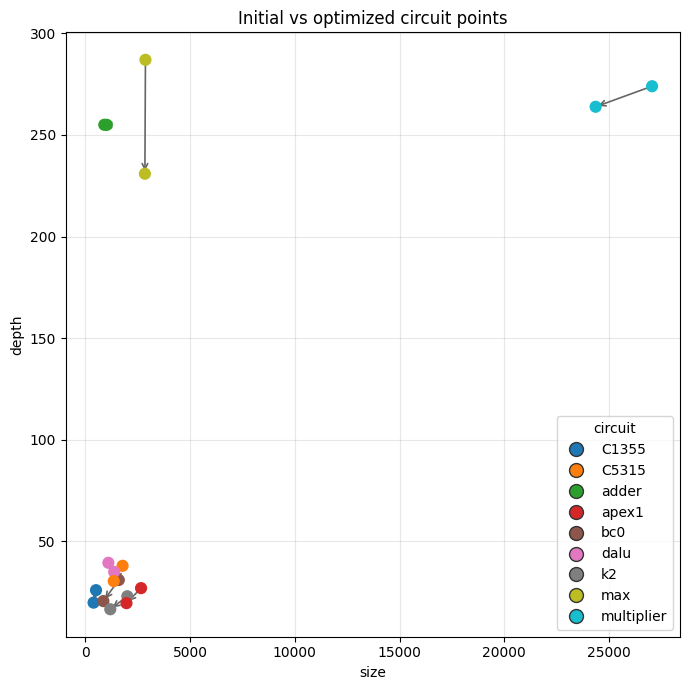

In [94]:
group_points = (
    points_df[["circuit", "size", "depth", "initial_size", "initial_depth"]]
    .groupby("circuit")
    .agg("mean")
)
print(len(group_points))

f, ax = plt.subplots(figsize=(7, 7))

cmap = plt.get_cmap("tab10")          # or "tab20", "viridis", "Set1", ...
n = 9
colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

ax.scatter(
    group_points["initial_size"],
    group_points["initial_depth"],
    s=60,
    zorder=3,
    color=colors
)
ax.scatter(
    group_points["size"],
    group_points["depth"],
    s=60,
    zorder=3,
    color=colors
)

for circuit, row in group_points.iterrows():
    ax.annotate(
        "",
        xy=(row["size"], row["depth"]),
        xytext=(row["initial_size"], row["initial_depth"]),
        arrowprops=dict(arrowstyle="->", color="0.4", lw=1.2),
        zorder=2,
    )
    # ax.annotate(
    #     circuit,
    #     xy=(row["size"], row["depth"]),
    #     xytext=(6, 4),
    #     textcoords="offset points",
    #     fontsize=9,
    # )

ax.set_xlabel("size")
ax.set_ylabel("depth")
ax.set_title("Initial vs optimized circuit points")

handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",                 # line color (invisible)
        markerfacecolor=color,
        markeredgecolor="0.2",
        markersize=10,
        label=name,
    )
    for color, name in zip(colors, group_points.index)
]
ax.legend(handles=handles, title="circuit")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## All Per-Run Pareto Fronts Across Test Circuits

Each panel contains every per-run Pareto front available for that circuit. Runs from the same experiment share a color; transparency exposes between-run variability without pooling seeds into one apparently deterministic front. Every circuit present in `points_df` is included, and lower-left is better.

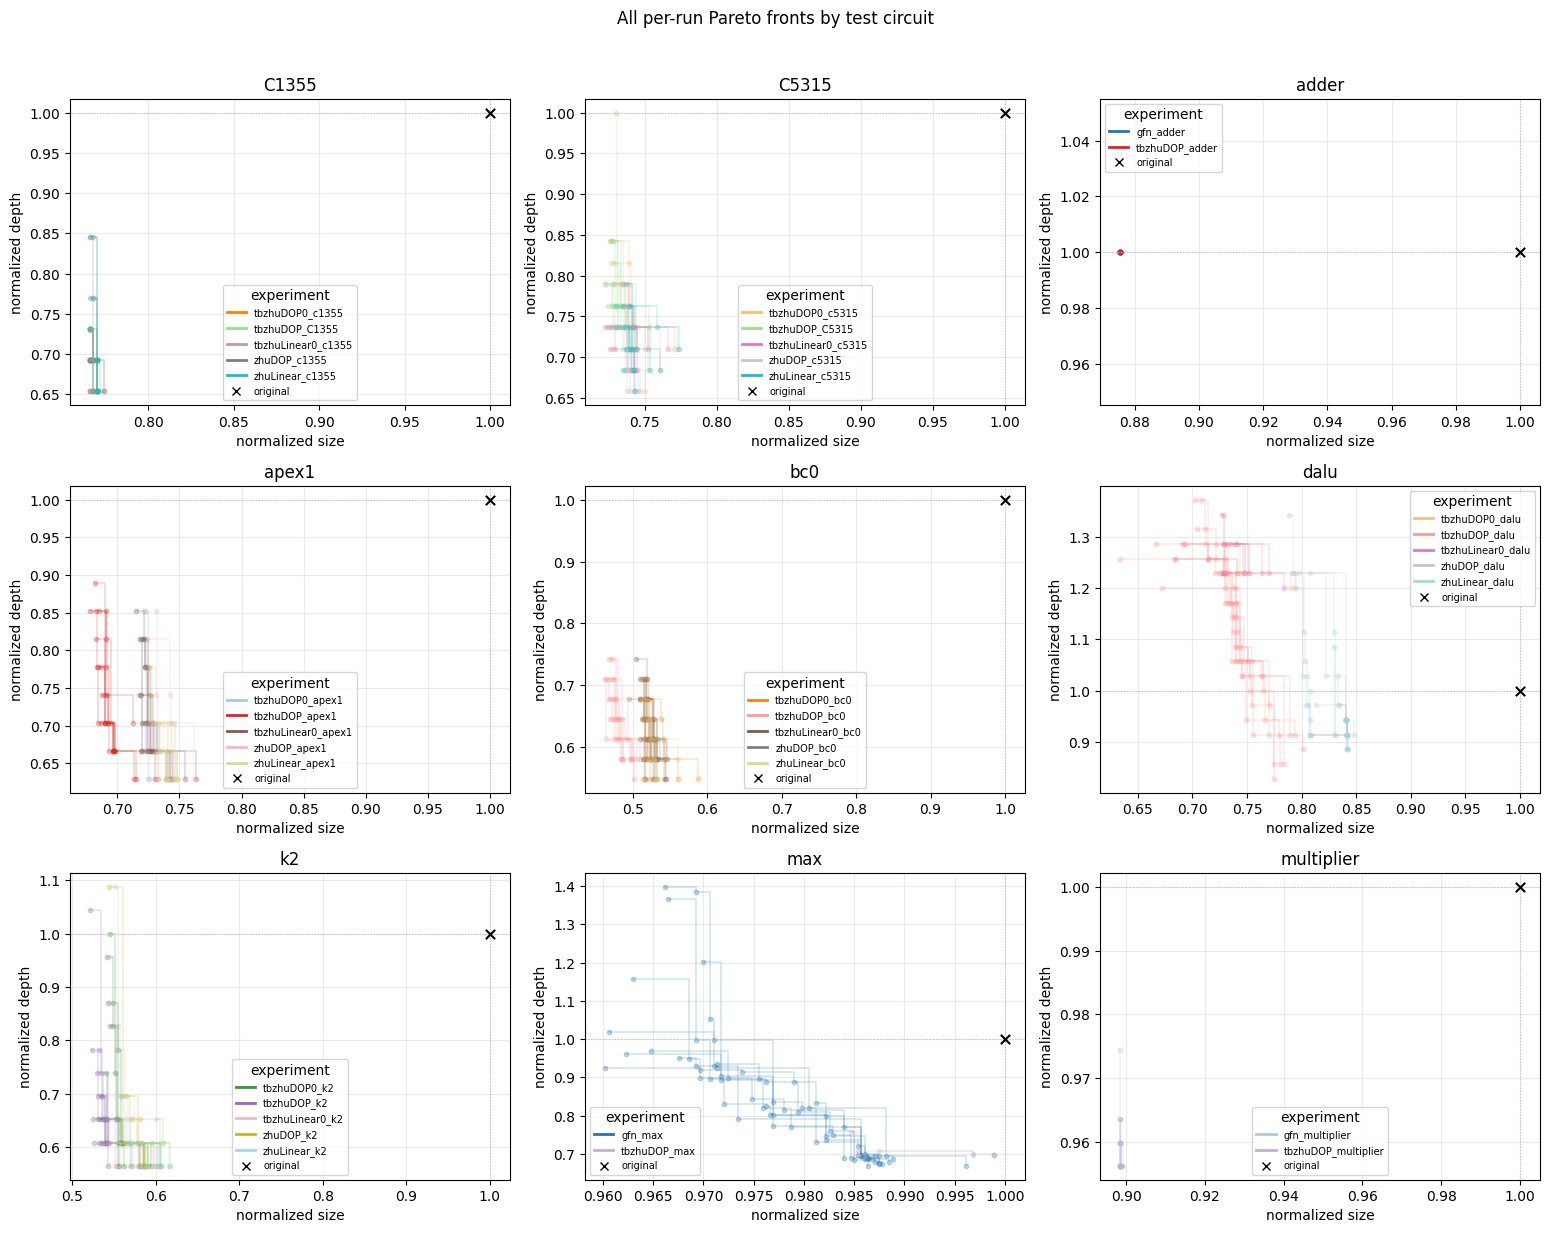

In [95]:
all_circuits = sorted(summary_df["circuit"].unique())
all_experiments = sorted(summary_df["run_name"].unique())
if not all_circuits:
    raise ValueError("No circuits are available to plot.")

experiment_cmap = plt.get_cmap("tab20", max(len(all_experiments), 1))
experiment_colors = {
    run_name: experiment_cmap(index)
    for index, run_name in enumerate(all_experiments)
}

n_columns = min(3, len(all_circuits))
n_rows = (len(all_circuits) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.2 * n_columns, 4.2 * n_rows),
    squeeze=False,
)

for ax, circuit in zip(axes.flat, all_circuits):
    present_experiments = []
    for run_name in all_experiments:
        run_fronts = sorted(
            (
                (run_id, front)
                for (name, run_id, front_circuit), front in fronts.items()
                if name == run_name and front_circuit == circuit and front
            ),
            key=lambda item: item[0],
        )
        if run_fronts:
            present_experiments.append(run_name)
        for run_id, front in run_fronts:
            front_array = np.asarray(sorted(front), dtype=float)
            ax.step(
                front_array[:, 0],
                front_array[:, 1],
                where="post",
                color=experiment_colors[run_name],
                linewidth=1.1,
                alpha=0.22,
            )
            ax.scatter(
                front_array[:, 0],
                front_array[:, 1],
                color=experiment_colors[run_name],
                s=10,
                alpha=0.28,
            )

    ax.scatter([1.0], [1.0], marker="x", s=45, color="black", zorder=5)
    ax.axvline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.axhline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.set_title(str(circuit))
    ax.set_xlabel("normalized size")
    ax.set_ylabel("normalized depth")
    ax.grid(True, alpha=0.25)
    circuit_legend_handles = [
        Line2D([0], [0], color=experiment_colors[name], linewidth=2, label=name)
        for name in present_experiments
    ]
    circuit_legend_handles.append(
        Line2D([0], [0], marker="x", color="black", linestyle="None", label="original")
    )
    ax.legend(handles=circuit_legend_handles, fontsize=7, title="experiment")

for ax in axes.flat[len(all_circuits):]:
    ax.remove()

fig.suptitle("All per-run Pareto fronts by test circuit", y=0.995)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()


## Mean Attainment Fronts With Run-Level Confidence Intervals

Pareto fronts do not have naturally corresponding point indices, so directly averaging their first, second, and third points would be arbitrary. Instead, each run is converted to a depth-attainment curve: at every normalized-size threshold, the curve records the best depth attained by that run at or below the threshold. Curves are compared only over the common size support reached by every run of that experiment.

The solid line is the pointwise mean attainment curve. The shaded region is a pointwise 95% percentile confidence interval for that mean, obtained by bootstrapping complete training runs. Resampling complete runs preserves each front as a unit and does not treat its sampled endpoints as independent training replicates. The interval therefore describes between-run uncertainty conditional on the existing evaluation samples; it is not a simultaneous confidence band and does not include a second-level bootstrap of evaluation trajectories.

   circuit            run_name  n_runs  hypervolume_mean  extended_hypervolume_mean
     C1355     tbzhuDOP0_c1355      10          0.075557                   0.105917
     C1355      tbzhuDOP_C1355      10          0.075588                   0.105948
     C1355  tbzhuLinear0_c1355      10          0.075595                   0.105955
     C1355        zhuDOP_c1355      10          0.076763                   0.107428
     C1355     zhuLinear_c1355      10          0.075633                   0.106067
     C5315     tbzhuDOP0_c5315      10          0.077858                   0.108425
     C5315      tbzhuDOP_C5315      10          0.075575                   0.105711
     C5315  tbzhuLinear0_c5315      10          0.080464                   0.111463
     C5315        zhuDOP_c5315      10          0.085232                   0.117149
     C5315     zhuLinear_c5315      10          0.080908                   0.112029
     adder           gfn_adder      10          0.000000                   0

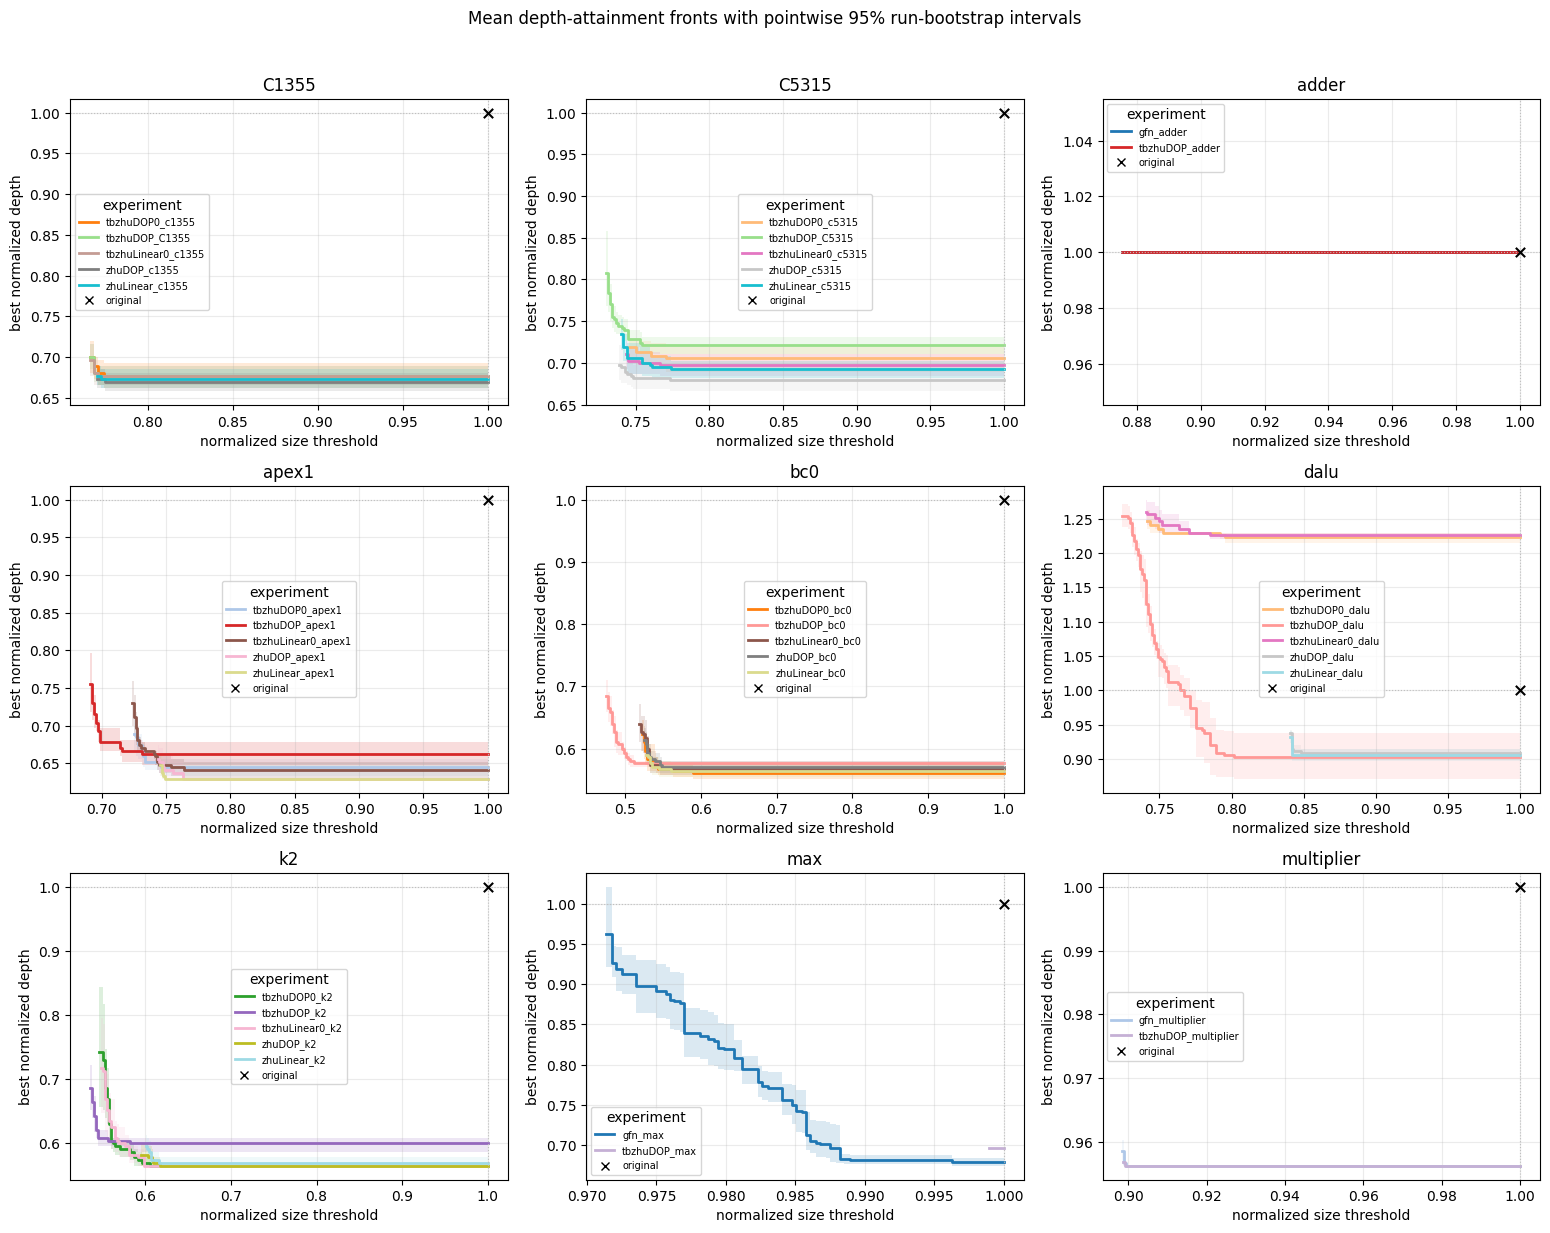

In [96]:
def depth_attainment_curve(front, size_grid):
    """Best normalized depth attained with normalized size <= each threshold."""
    front_array = np.asarray(front, dtype=float)
    curve = np.empty(len(size_grid), dtype=float)
    for index, size_threshold in enumerate(size_grid):
        eligible = front_array[:, 0] <= size_threshold + 1.0e-12
        curve[index] = np.min(front_array[eligible, 1]) if eligible.any() else np.nan
    return curve


def mean_front_with_run_bootstrap(
    run_fronts,
    *,
    grid_size=200,
    n_bootstrap=2000,
    confidence_level=0.95,
    rng,
):
    """Mean depth-attainment front and pointwise run-bootstrap confidence interval."""
    run_fronts = [front for front in run_fronts if front]
    if not run_fronts:
        raise ValueError("At least one non-empty run front is required.")

    # This lower bound ensures every run contributes at every grid point.
    common_min_size = max(min(point[0] for point in front) for front in run_fronts)
    max_size = max(1.0, max(max(point[0] for point in front) for front in run_fronts))
    size_grid = np.linspace(common_min_size, max_size, grid_size)
    run_curves = np.vstack(
        [depth_attainment_curve(front, size_grid) for front in run_fronts]
    )
    if np.isnan(run_curves).any():
        raise ValueError("Common-support construction unexpectedly produced missing values.")

    mean_depth = run_curves.mean(axis=0)
    if len(run_curves) < 2:
        ci_low = np.full_like(mean_depth, np.nan)
        ci_high = np.full_like(mean_depth, np.nan)
    else:
        bootstrap_indices = rng.integers(
            0,
            len(run_curves),
            size=(n_bootstrap, len(run_curves)),
        )
        bootstrap_means = run_curves[bootstrap_indices].mean(axis=1)
        tail_probability = (1.0 - confidence_level) / 2.0
        ci_low, ci_high = np.quantile(
            bootstrap_means,
            [tail_probability, 1.0 - tail_probability],
            axis=0,
        )

    return pd.DataFrame(
        {
            "normalized_size": size_grid,
            "mean_normalized_depth": mean_depth,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n_runs": len(run_curves),
        }
    )


mean_front_grid_size = 200
mean_front_bootstrap_repetitions = 2000
mean_front_confidence_level = 0.95
mean_front_rng = np.random.default_rng(42)

mean_front_frames = []
for circuit in all_circuits:
    for run_name in all_experiments:
        experiment_fronts = [
            front
            for (name, _, front_circuit), front in fronts.items()
            if name == run_name and front_circuit == circuit and front
        ]
        if not experiment_fronts:
            continue
        mean_front = mean_front_with_run_bootstrap(
            experiment_fronts,
            grid_size=mean_front_grid_size,
            n_bootstrap=mean_front_bootstrap_repetitions,
            confidence_level=mean_front_confidence_level,
            rng=mean_front_rng,
        )
        mean_front.insert(0, "run_name", run_name)
        mean_front.insert(0, "circuit", circuit)
        mean_front_frames.append(mean_front)

mean_front_df = pd.concat(mean_front_frames, ignore_index=True)
mean_front_run_counts = (
    mean_front_df.groupby(["circuit", "run_name"], as_index=False)["n_runs"]
    .first()
    .merge(
        aggregate_summary_df[
            ["circuit", "run_name", "hypervolume_mean", "extended_hypervolume_mean"]
        ],
        on=["circuit", "run_name"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["circuit", "run_name"])
)
print(mean_front_run_counts.to_string(index=False))

n_columns = min(3, len(all_circuits))
n_rows = (len(all_circuits) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.2 * n_columns, 4.2 * n_rows),
    squeeze=False,
)

for ax, circuit in zip(axes.flat, all_circuits):
    present_experiments = []
    for run_name in all_experiments:
        curve = mean_front_df[
            (mean_front_df["circuit"] == circuit)
            & (mean_front_df["run_name"] == run_name)
        ]
        if curve.empty:
            continue
        present_experiments.append(run_name)
        color = experiment_colors[run_name]
        ax.step(
            curve["normalized_size"],
            curve["mean_normalized_depth"],
            where="post",
            color=color,
            linewidth=2.0,
        )
        if curve["n_runs"].iloc[0] >= 2:
            ax.fill_between(
                curve["normalized_size"],
                curve["ci_low"],
                curve["ci_high"],
                step="post",
                color=color,
                alpha=0.16,
                linewidth=0,
            )

    ax.scatter([1.0], [1.0], marker="x", s=45, color="black", zorder=5)
    ax.axvline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.axhline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.set_title(str(circuit))
    ax.set_xlabel("normalized size threshold")
    ax.set_ylabel("best normalized depth")
    ax.grid(True, alpha=0.25)
    circuit_legend_handles = [
        Line2D([0], [0], color=experiment_colors[name], linewidth=2, label=name)
        for name in present_experiments
    ]
    circuit_legend_handles.append(
        Line2D([0], [0], marker="x", color="black", linestyle="None", label="original")
    )
    ax.legend(handles=circuit_legend_handles, fontsize=7, title="experiment")

for ax in axes.flat[len(all_circuits):]:
    ax.remove()

fig.suptitle("Mean depth-attainment fronts with pointwise 95% run-bootstrap intervals", y=0.995)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [97]:
# Choose the comparison target.
selected_circuit = points_df["circuit"].unique()[1]
# selected_circuit = 'bc0'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

circ_sum_df = summary_df.loc[
    summary_df["circuit"] == selected_circuit,
    ["run_name", "hypervolume", "extended_hypervolume", "number of nondominated points"]
].groupby("run_name").agg("mean")
circ_sum_df

Selected circuit: max
Selected experiments: ['gfn_max', 'tbzhuDOP_max']


,hypervolume,extended_hypervolume,number of nondominated points
run_name,,,
gfn_max,0.007032,0.027205,7.6
tbzhuDOP_max,0.003151,0.021382,1.6


In [98]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)
    source_extended_hypervolumes = [
        hypervolume_min_2d(front, EXTENDED_HYPERVOLUME_REFERENCE)
        for front in source_fronts.values()
    ]
    target_extended_hypervolumes = [
        hypervolume_min_2d(front, EXTENDED_HYPERVOLUME_REFERENCE)
        for front in target_fronts.values()
    ]

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "source_extended_hypervolume_mean": fmean(source_extended_hypervolumes),
            "target_extended_hypervolume_mean": fmean(target_extended_hypervolumes),
            "extended_hypervolume_mean_difference": (
                fmean(source_extended_hypervolumes)
                - fmean(target_extended_hypervolumes)
            ),
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,source_extended_hypervolume_mean,target_extended_hypervolume_mean,extended_hypervolume_mean_difference,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,gfn_max,tbzhuDOP_max,max,100,0.027205,0.021382,0.005822,-0.002609,0.004962,0.000496,-0.013937,0.003490,0.633333,0.443471,0.044347,0.0,1.000000
1,tbzhuDOP_max,gfn_max,max,100,0.021382,0.027205,-0.005822,0.025271,0.006937,0.000694,0.013264,0.038743,0.037956,0.084276,0.008428,0.0,0.333333


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [99]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
selected_front_summary_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    selected_front_summary_rows.append(
        {
            "run_name": run_name,
            "circuit": selected_circuit,
            "hypervolume": hypervolume_min_2d(pooled_front, HYPERVOLUME_REFERENCE),
            "extended_hypervolume": hypervolume_min_2d(
                pooled_front, EXTENDED_HYPERVOLUME_REFERENCE
            ),
            "number of nondominated points": len(pooled_front),
        }
    )
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "pooled_hypervolume": hypervolume_min_2d(
                    pooled_front, HYPERVOLUME_REFERENCE
                ),
                "pooled_extended_hypervolume": hypervolume_min_2d(
                    pooled_front, EXTENDED_HYPERVOLUME_REFERENCE
                ),
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_summary_df = pd.DataFrame(selected_front_summary_rows).sort_values(
    ["run_name"]
).reset_index(drop=True)
selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print("Pooled-front metrics:")
print(selected_front_summary_df.to_string(index=False))
print("Pooled-front points:")
print(selected_front_df.to_string(index=False))
selected_front_summary_df, selected_front_df

Pareto fronts for circuit: max
Experiments: ['gfn_max', 'tbzhuDOP_max']
Pooled-front metrics:
    run_name circuit  hypervolume  extended_hypervolume  number of nondominated points
     gfn_max     max     0.008923              0.029963                             12
tbzhuDOP_max     max     0.004711              0.023485                              3
Pooled-front points:
    run_name circuit  pooled_hypervolume  pooled_extended_hypervolume  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
     gfn_max     max            0.008923                     0.029963         0.960209          0.923345        0.039791         0.076655  2751    265
     gfn_max     max            0.008923                     0.029963         0.969634          0.898955        0.030366         0.101045  2778    258
     gfn_max     max            0.008923                     0.029963         0.970681          0.895470        0.029319         0.104530  2781    257
     gfn_max     max

(       run_name circuit  hypervolume  extended_hypervolume  \
 0       gfn_max     max     0.008923              0.029963   
 1  tbzhuDOP_max     max     0.004711              0.023485   
 
    number of nondominated points  
 0                             12  
 1                              3  ,
         run_name circuit  pooled_hypervolume  pooled_extended_hypervolume  \
 0        gfn_max     max            0.008923                     0.029963   
 1        gfn_max     max            0.008923                     0.029963   
 2        gfn_max     max            0.008923                     0.029963   
 3        gfn_max     max            0.008923                     0.029963   
 4        gfn_max     max            0.008923                     0.029963   
 5        gfn_max     max            0.008923                     0.029963   
 6        gfn_max     max            0.008923                     0.029963   
 7        gfn_max     max            0.008923                     0.029963  

## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

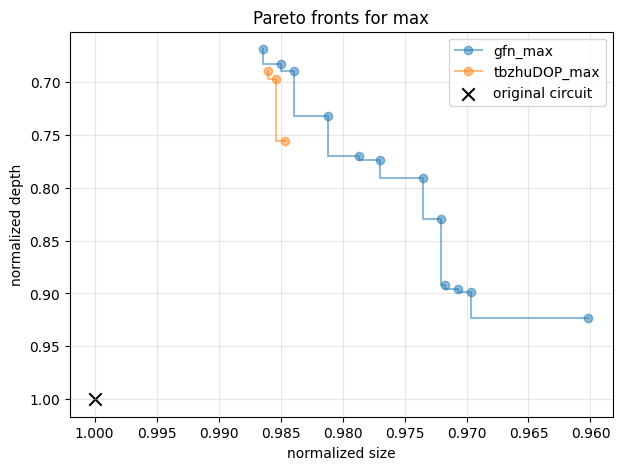

In [100]:
fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        alpha=0.5,
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()